In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno


In [3]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [4]:
df_productivity = pd.read_csv(PATH)
df_productivity.head()

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


In [5]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


In [6]:
df_productivity.shape

(3248, 34)

In [7]:
df_productivity.info()

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

In [8]:
df_productivity.columns

Index(['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type',
       'seniority', 'task_complexity_score', 'brief_quality_score',
       'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at',
       'delivered_at', 'sla_days', 'sla_breach', 'hours_spent',
       'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors',
       'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit',
       'created_by', 'updated_at', 'task_status', 'workflow_stage',
       'jira_ticket', 'legacy_ai_flag', 'content_version'],
      dtype='str')

In [9]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


## MISSING VALUES

In [10]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

jira_ticket            339
ai_usage_pct           144
outcome_score          133
billable_hours          82
rework_hours            72
brief_quality_score     69
delivered_at            38
sla_days                36
dtype: int64

In [11]:

missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
missing_pct.sort_values(ascending=False)

jira_ticket              10.437192
ai_usage_pct              4.433498
outcome_score             4.094828
billable_hours            2.524631
rework_hours              2.216749
brief_quality_score       2.124384
delivered_at              1.169951
sla_days                  1.108374
workflow_stage            0.000000
task_status               0.000000
updated_at                0.000000
created_by                0.000000
ai_assisted               0.000000
cost                      0.000000
revenue                   0.000000
legacy_ai_flag            0.000000
errors                    0.000000
revisions                 0.000000
profit                    0.000000
task_id                   0.000000
client                    0.000000
hours_spent               0.000000
sla_breach                0.000000
created_at                0.000000
pricing_model             0.000000
scope_change_flag         0.000000
deadline_pressure         0.000000
task_complexity_score     0.000000
seniority           

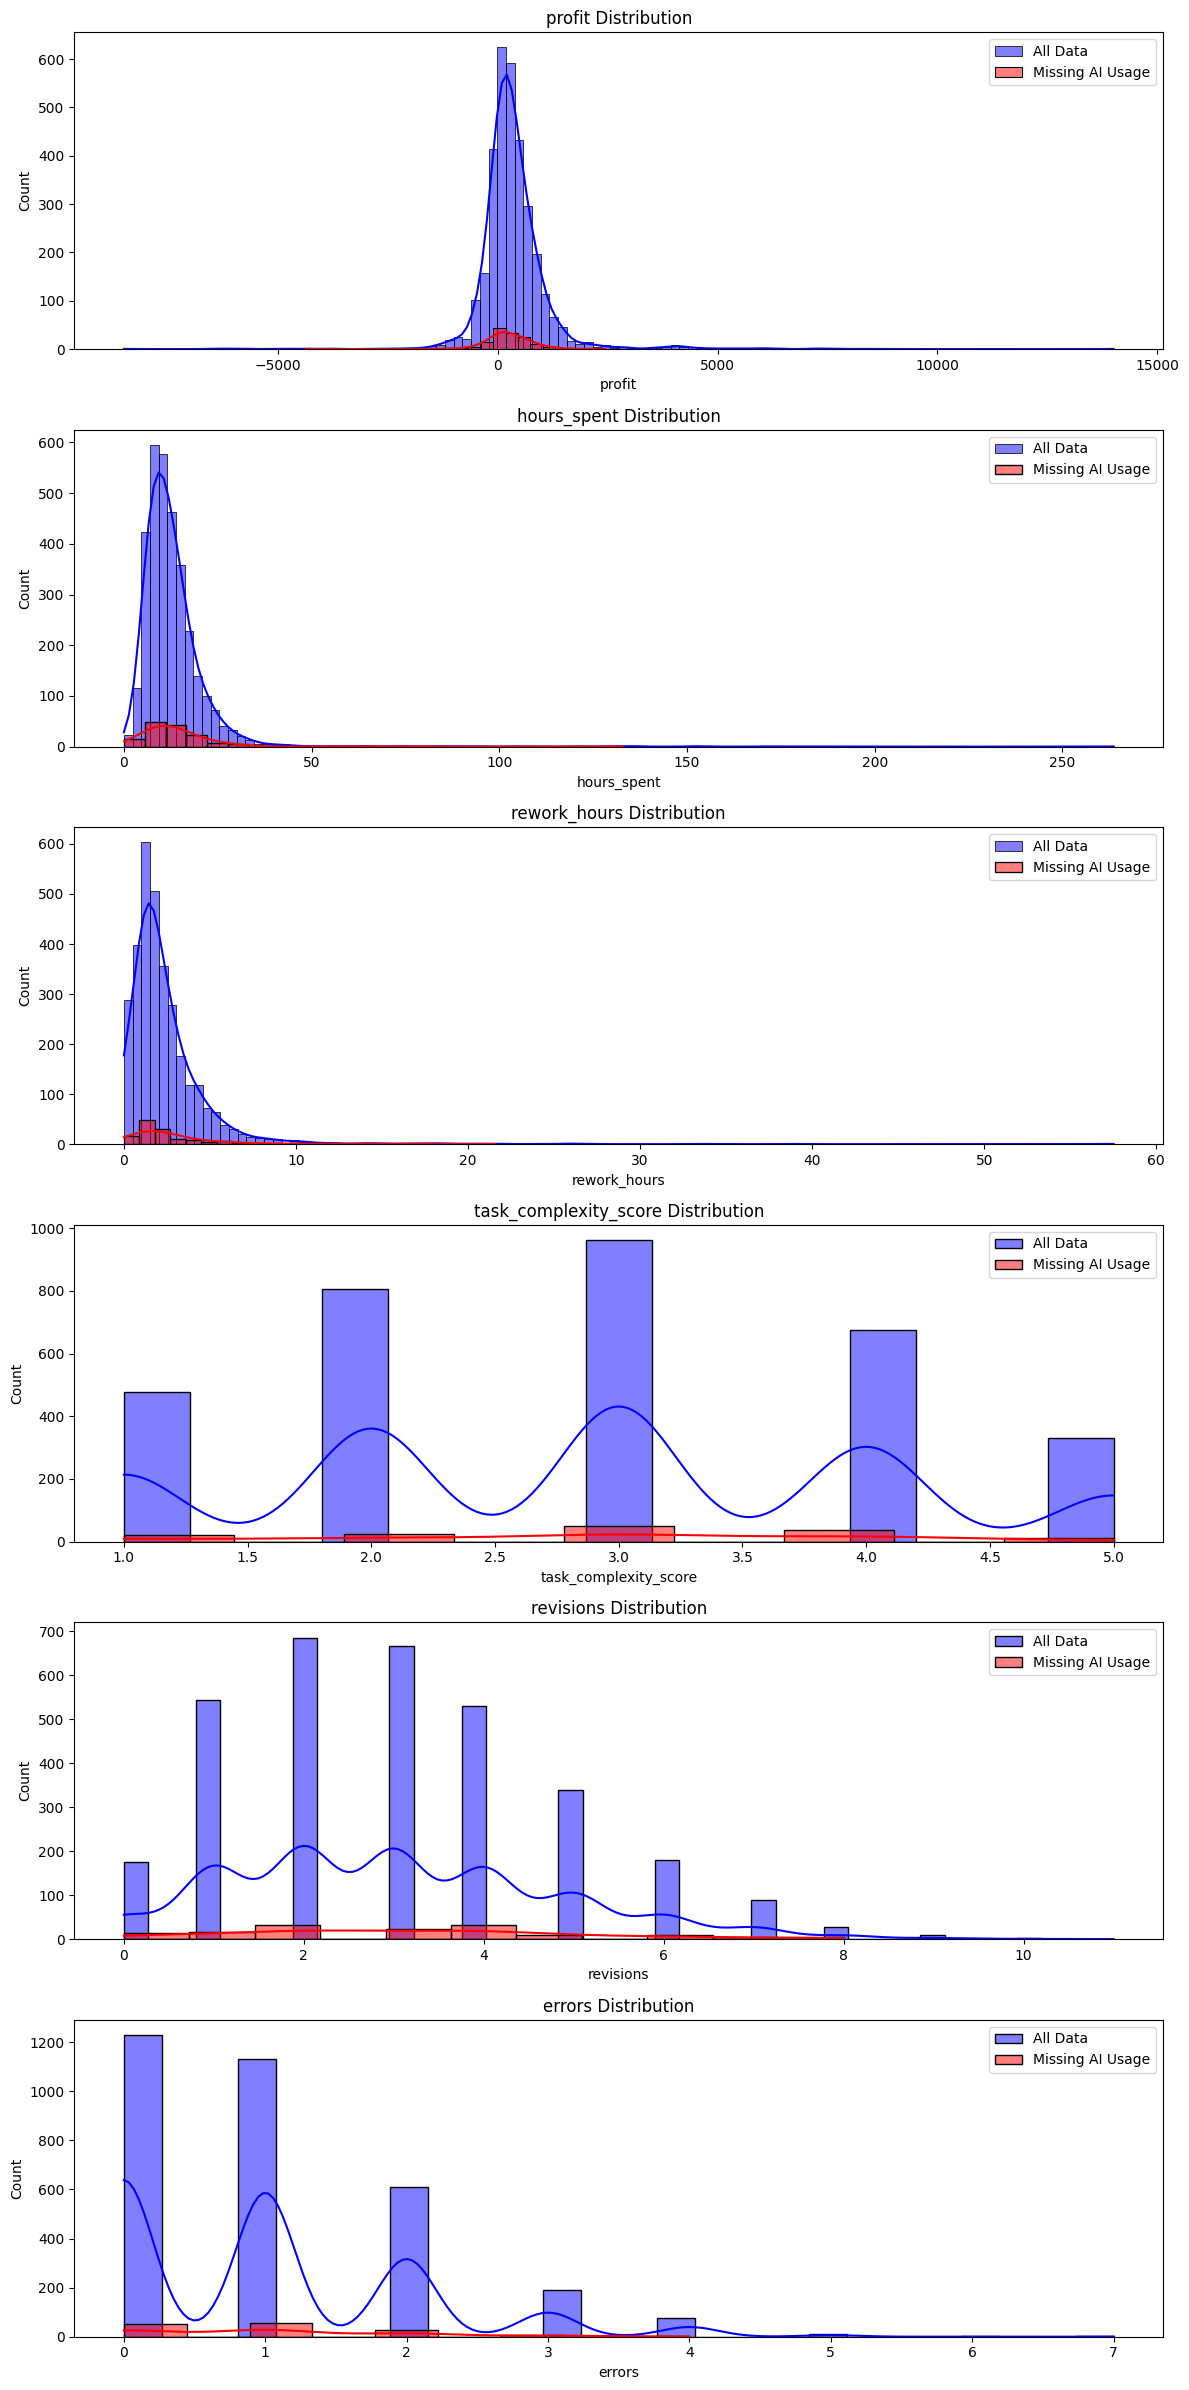

In [ ]:
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]


columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors'
]


fig, axes = plt.subplots(len(columns), 1, figsize=(12, 4 * len(columns)))


for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, x=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, x=column, ax=axes[i], color='red', label='Missing AI Usage')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()


plt.tight_layout()
plt.show()

<Axes: >

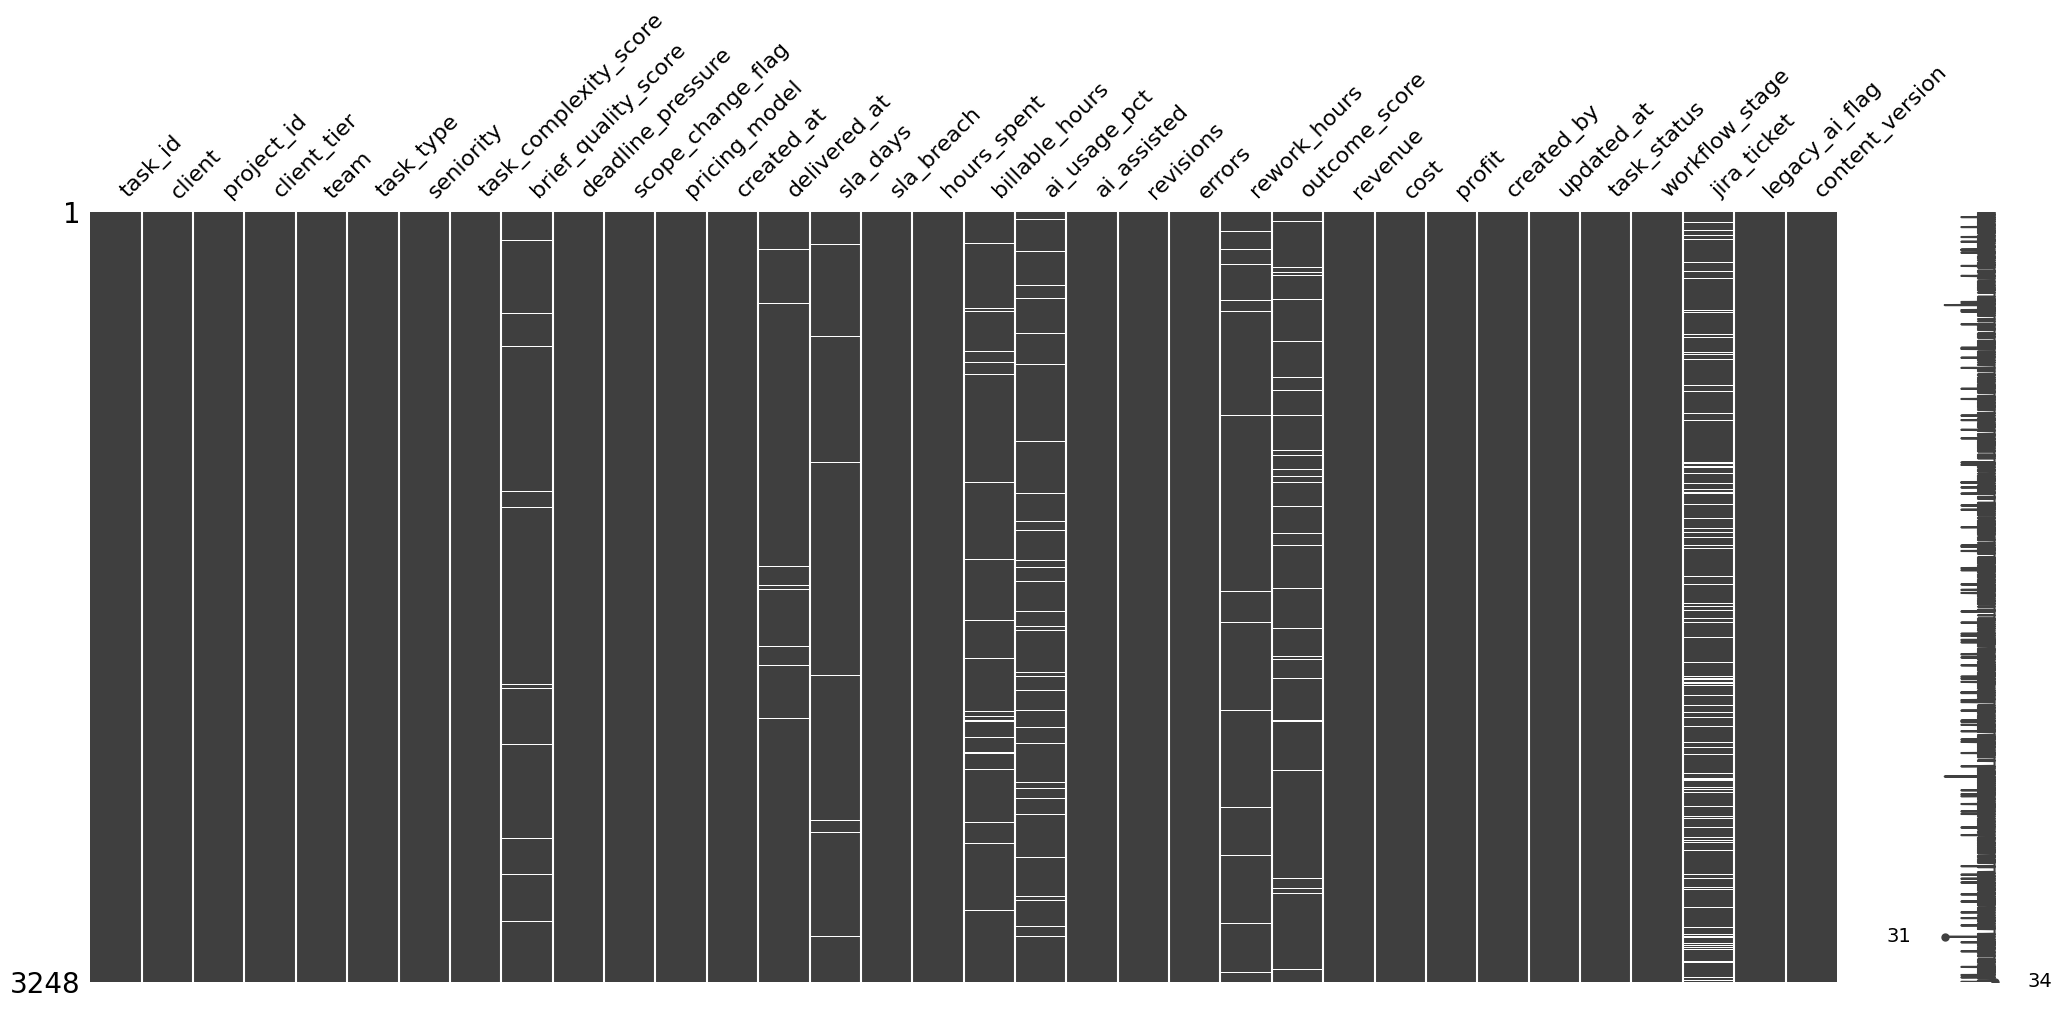

In [13]:
msno.matrix(df_productivity)

**taking care of nans**

In [14]:
df_productivity = df_productivity.drop(columns=['jira_ticket'])


df_productivity['rework_hours'].fillna(0, inplace=True)


df_productivity['billable_hours'].fillna(df_productivity['billable_hours'].median(), inplace=True)
df_productivity['brief_quality_score'].fillna(df_productivity['brief_quality_score'].median(), inplace=True)


df_productivity['outcome_score'].fillna(df_productivity['outcome_score'].median(), inplace=True)


df_ai = df_productivity[df_productivity['ai_usage_pct'].notna()]

/var/folders/sy/rj38yfc5325c80xyvrvsb31m0000gn/T/ipykernel_33783/1587731040.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_productivity['rework_hours'].fillna(0, inplace=True)
/var/folders/sy/rj38yfc5325c80xyvrvsb31m0000gn/T/ipykernel_33783/1587731040.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame

# Duplicates check

In [15]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


# Outlier check


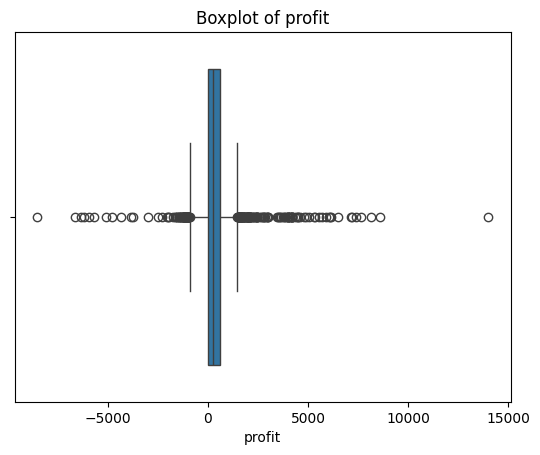

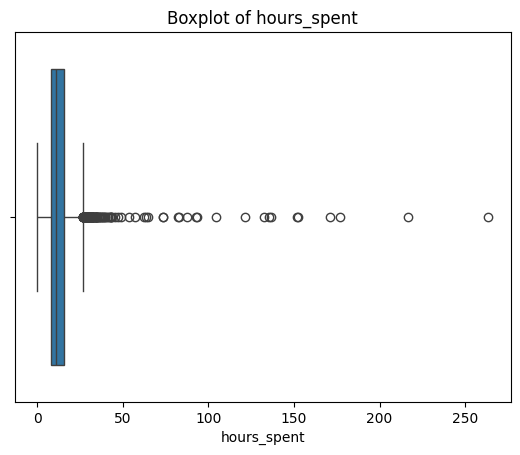

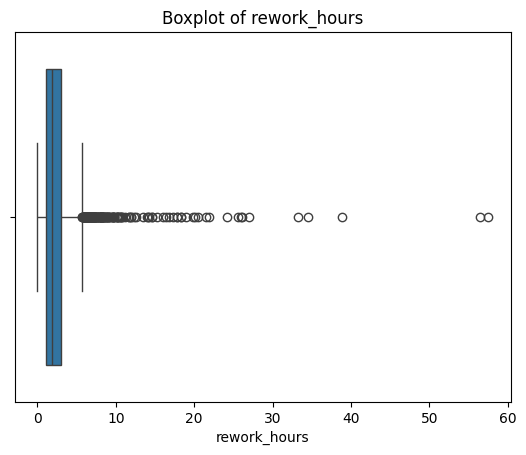

In [16]:
num_cols = ['profit', 'hours_spent', 'rework_hours']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_productivity[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

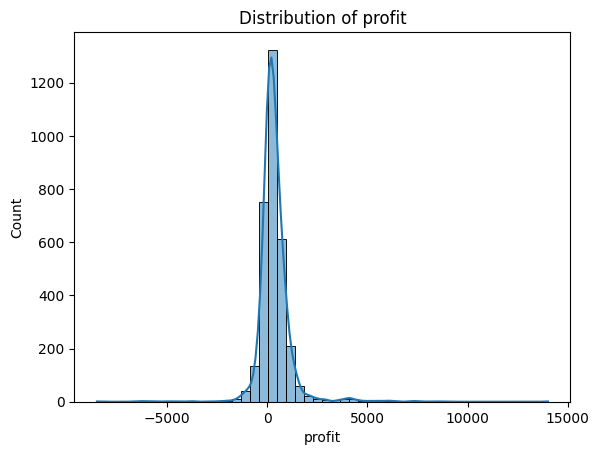

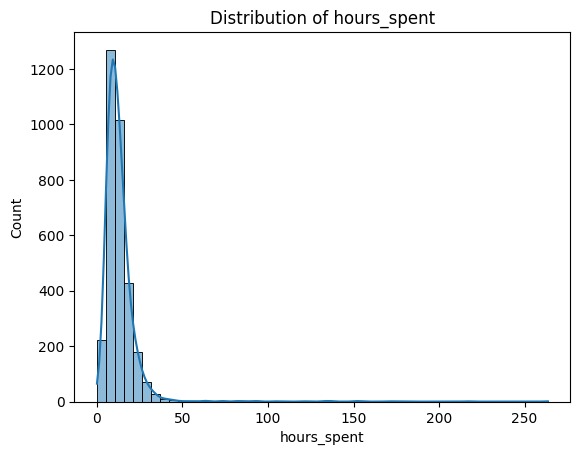

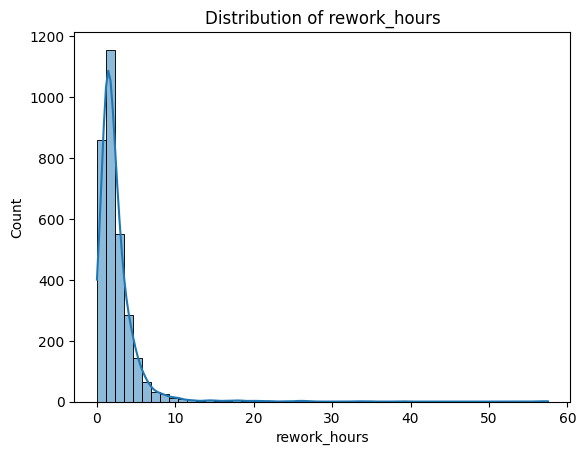

In [17]:
for col in num_cols:
    plt.figure()
    sns.histplot(df_productivity[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [18]:
for col in num_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_productivity[
        (df_productivity[col] < lower) | 
        (df_productivity[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

profit: 190 outliers
hours_spent: 136 outliers
rework_hours: 182 outliers


In [19]:
for col in num_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_productivity[
        (df_productivity[col] < lower) | 
        (df_productivity[col] > upper)
    ]

    perc = len(outliers) / len(df_productivity) * 100
    print(f"{col}: {perc:.2f}% outliers")

profit: 5.85% outliers
hours_spent: 4.19% outliers
rework_hours: 5.60% outliers


## Outlier Analysis

Boxplots and IQR-based analysis reveal the presence of outliers in key variables such as profit, hours_spent, and rework_hours.

The proportion of outliers is moderate:
- profit: 5.85%
- hours_spent: 4.19%
- rework_hours: 5.60%

This suggests that extreme values are present but not dominant.

Given the operational nature of the dataset, these observations likely reflect real-world variability (e.g., highly complex tasks or unusual execution conditions) rather than data errors.

Therefore, outliers are retained during exploratory analysis, but their impact will be controlled in subsequent modeling steps.

## Target Variable : Profit

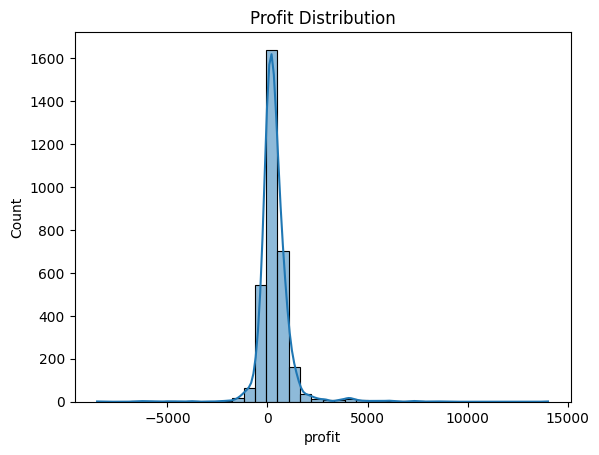

In [20]:
sns.histplot(df_productivity['profit'], bins=40, kde=True)
plt.title("Profit Distribution")
plt.show()

## AI usage 

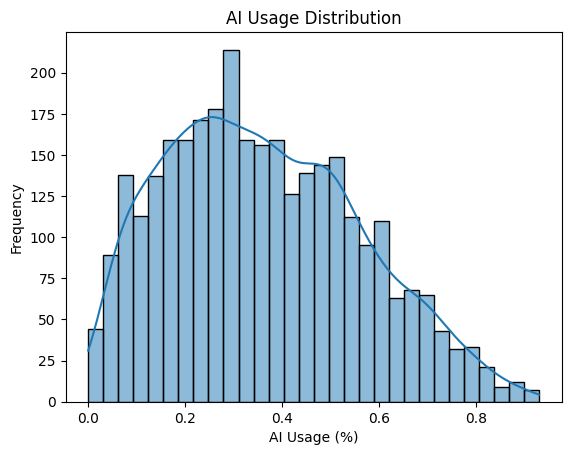

In [21]:
sns.histplot(df_productivity['ai_usage_pct'], bins=30, kde=True)
plt.title("AI Usage Distribution")
plt.xlabel("AI Usage (%)")
plt.ylabel("Frequency")
plt.show()

In [22]:
df_productivity['ai_usage_pct'].describe()

count    3104.000000
mean        0.361717
std         0.199391
min         0.000000
25%         0.200000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

## efficiency vs quality

**time**


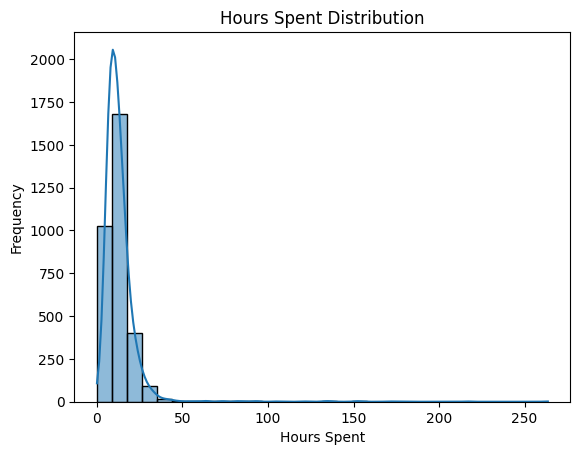

In [23]:
sns.histplot(df_productivity['hours_spent'], bins=30, kde=True)
plt.title("Hours Spent Distribution")
plt.xlabel("Hours Spent")
plt.ylabel("Frequency")
plt.show()

**rework**

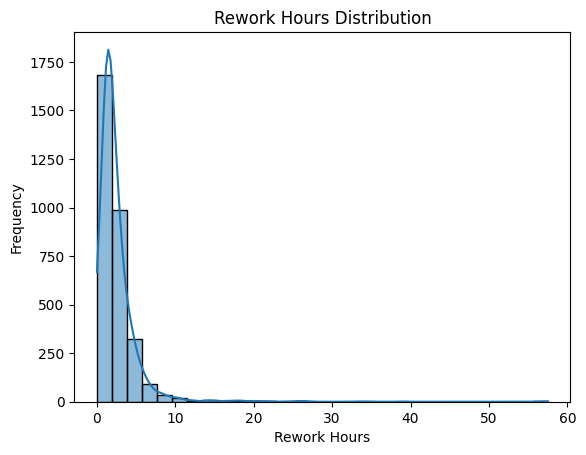

In [24]:
sns.histplot(df_productivity['rework_hours'], bins=30, kde=True)
plt.title("Rework Hours Distribution")
plt.xlabel("Rework Hours")
plt.ylabel("Frequency")
plt.show()

## Correlation

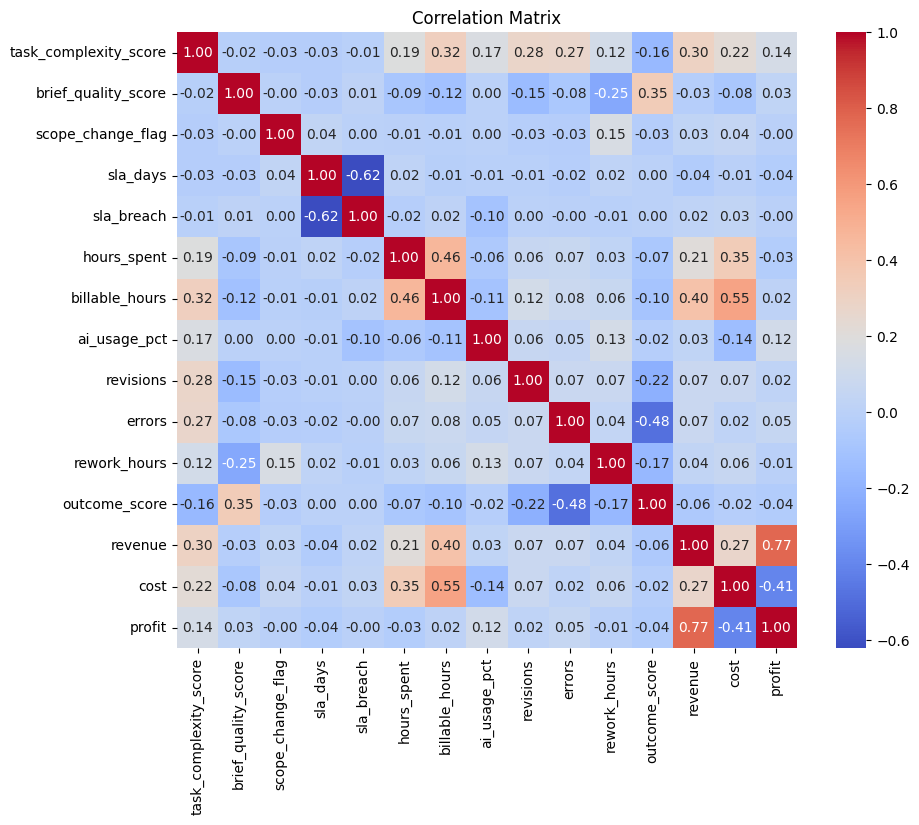

In [25]:
numeric = df_productivity.select_dtypes(include=[np.number])

corr = numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

## Bivariate

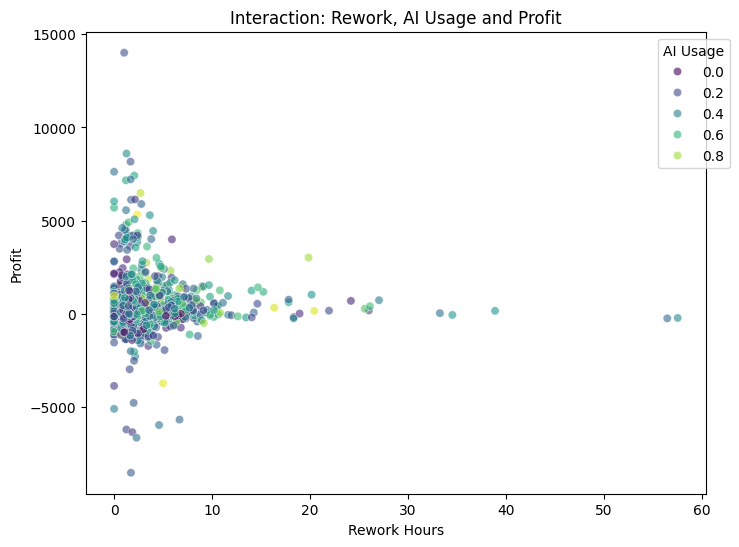

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='rework_hours',
    y='profit',
    hue='ai_usage_pct',
    palette='viridis',
    data=df_productivity,
    alpha=0.6
)

plt.title("Interaction: Rework, AI Usage and Profit")
plt.xlabel("Rework Hours")
plt.ylabel("Profit")
plt.legend(title="AI Usage", bbox_to_anchor=(1.05, 1))
plt.show()

In [27]:

df_productivity['ai_bin'] = pd.cut(
    df_productivity['ai_usage_pct'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1]
)


threshold = df_productivity.groupby('ai_bin')[[
    'profit',
    'rework_hours',
    'hours_spent'
]].mean()

threshold

,profit,rework_hours,hours_spent
ai_bin,,,
"(0.0, 0.2]",228.407677,1.991325,13.294550
"(0.2, 0.4]",308.515103,2.291477,13.736317
"(0.4, 0.6]",471.705405,2.654575,12.814298
"(0.6, 0.8]",459.114219,3.008578,10.806067
"(0.8, 1.0]",723.356328,3.535106,10.942245


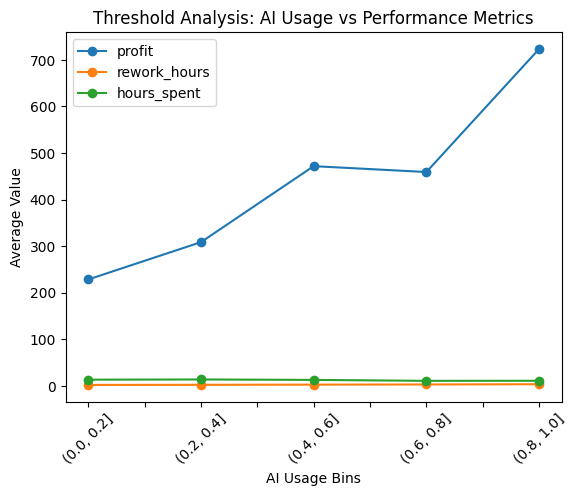

In [28]:
threshold.plot(marker='o')
plt.title("Threshold Analysis: AI Usage vs Performance Metrics")
plt.xlabel("AI Usage Bins")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

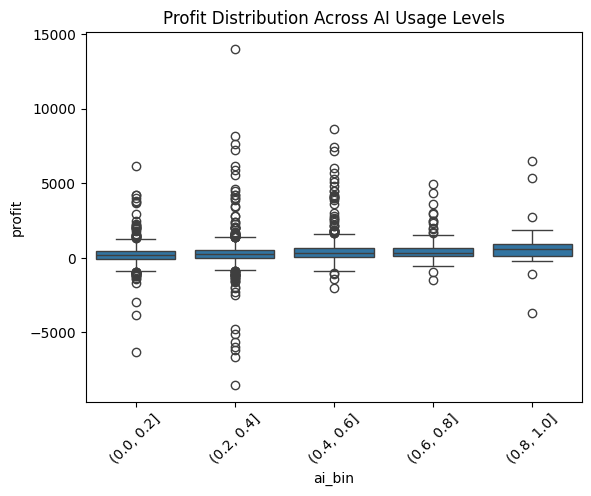

In [29]:
sns.boxplot(x='ai_bin', y='profit', data=df_productivity)
plt.xticks(rotation=45)
plt.title("Profit Distribution Across AI Usage Levels")
plt.show()

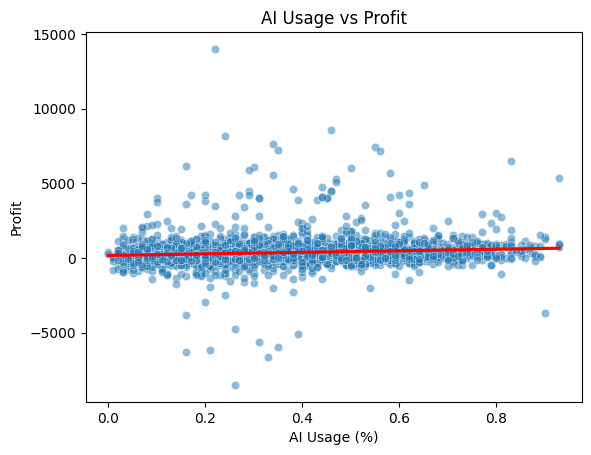

In [30]:
sns.scatterplot(x='ai_usage_pct', y='profit', data=df_productivity, alpha=0.5)


sns.regplot(x='ai_usage_pct', y='profit', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

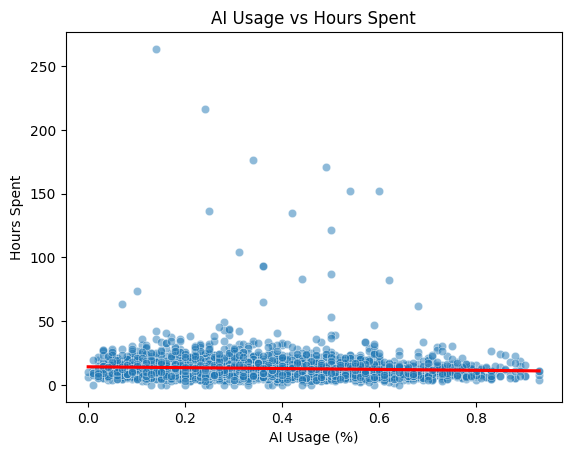

In [31]:
sns.scatterplot(x='ai_usage_pct', y='hours_spent', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='hours_spent', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Hours Spent")
plt.xlabel("AI Usage (%)")
plt.ylabel("Hours Spent")
plt.show()

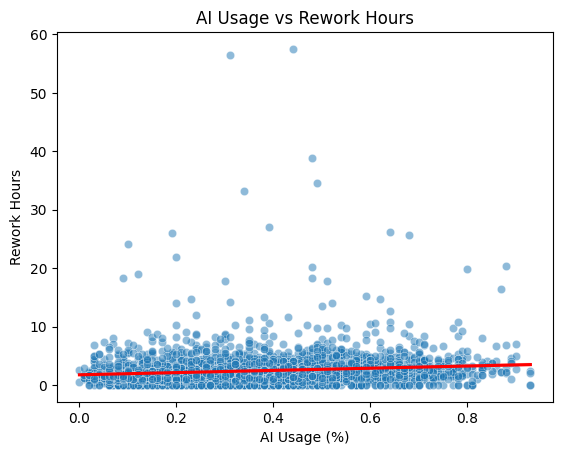

In [32]:
sns.scatterplot(x='ai_usage_pct', y='rework_hours', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='rework_hours', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Rework Hours")
plt.xlabel("AI Usage (%)")
plt.ylabel("Rework Hours")
plt.show()

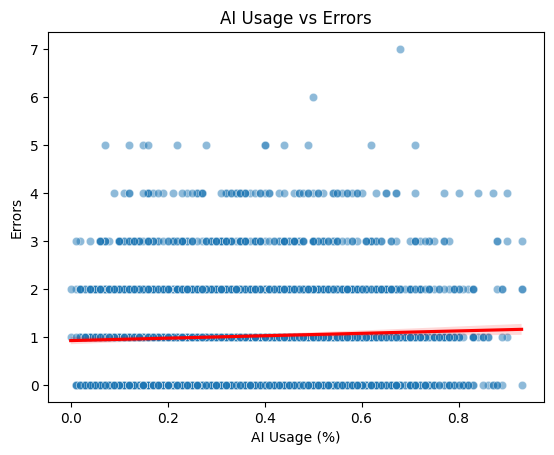

In [33]:
sns.scatterplot(x='ai_usage_pct', y='errors', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='errors', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Errors")
plt.xlabel("AI Usage (%)")
plt.ylabel("Errors")
plt.show()

# Feature Engineering (EDA-driven)

In [34]:
# --- QUALITY / RISK ---
# quanto del tempo totale è speso a correggere
df_productivity['rework_rate'] = df_productivity['rework_hours'] / df_productivity['hours_spent']

# error intensity
df_productivity['error_rate'] = df_productivity['errors'] / (df_productivity['hours_spent'] + 1)

# --- EFFICIENCY ---
# quanto tempo diventa fatturabile
df_productivity['efficiency_ratio'] = df_productivity['billable_hours'] / df_productivity['hours_spent']

# valore prodotto per ora
df_productivity['revenue_per_hour'] = df_productivity['revenue'] / df_productivity['hours_spent']

# costo per ora
df_productivity['cost_per_hour'] = df_productivity['cost'] / df_productivity['hours_spent']

# --- BUSINESS ---
# margine normalizzato (meglio del profit assoluto)
df_productivity['profit_margin'] = df_productivity['profit'] / df_productivity['revenue']

# --- AI ---
# uso vs non uso
df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)

# --- NON-LINEARITY (FONDAMENTALE) ---
# cattura il threshold che hai trovato
df_productivity['ai_usage_sq'] = df_productivity['ai_usage_pct'] ** 2

# --- CLEANUP ---
df_productivity.replace([np.inf, -np.inf], np.nan, inplace=True)

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,content_version,ai_bin,rework_rate,error_rate,efficiency_ratio,revenue_per_hour,cost_per_hour,profit_margin,ai_flag,ai_usage_sq
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,v1,"(0.6, 0.8]",0.275229,0.115875,0.673657,65.283093,45.369594,0.305033,1,0.5625
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,v1,"(0.0, 0.2]",0.470588,0.095057,0.863445,88.971639,36.048319,0.594834,1,0.0144
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,v2,"(0.2, 0.4]",0.320710,0.000000,0.727811,162.611834,43.197633,0.734351,1,0.1369
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,v1,"(0.0, 0.2]",0.000000,0.034072,0.854321,83.919224,53.429630,0.363321,1,0.0049
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,v2,"(0.0, 0.2]",0.141653,0.288600,0.748735,119.721754,56.537943,0.527755,1,0.0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3243,T02060,Client_F,P056,mid,SEO,report,mid,2,3.0,high,...,v1,"(0.4, 0.6]",0.027796,0.000000,0.047223,4.031648,4.725660,-0.172141,1,0.2401
3244,T02295,Client_K,P001,low,SEO,report,mid,1,2.0,high,...,v3,"(0.0, 0.2]",0.379683,0.000000,0.702450,41.112392,48.394813,-0.177134,1,0.0016
3245,T02652,Client_C,P027,mid,Content,dev,junior,4,3.0,medium,...,v4,"(0.6, 0.8]",0.251369,0.051921,0.775465,77.715772,71.398686,0.081284,1,0.5184
3246,T01915,Client_F,P016,mid,SEO,ticket,mid,3,3.0,medium,...,v1,"(0.2, 0.4]",0.409836,0.000000,0.702186,77.945355,74.748634,0.041012,1,0.0900


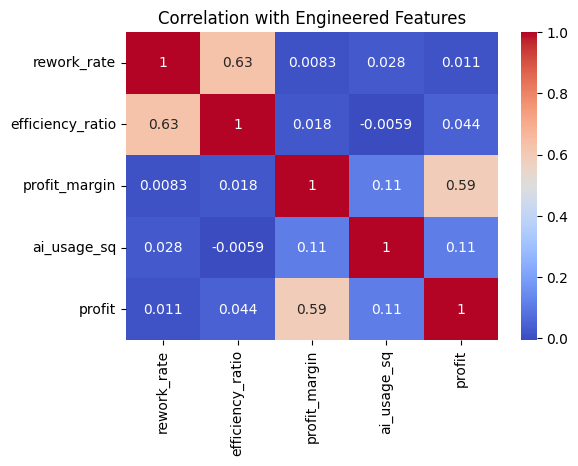

In [35]:
# Check correlation with new features
new_features = ['rework_rate', 'efficiency_ratio', 'profit_margin', 'ai_usage_sq']

corr = df_productivity[new_features + ['profit']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation with Engineered Features")
plt.show()

# AI vs NO AI

In [36]:
comparison = df_productivity.groupby('ai_flag')[[
    'profit', 
    'hours_spent', 
    'rework_hours', 
    'errors',
    'outcome_score'
]].mean().round(2)

print(comparison)

         profit  hours_spent  rework_hours  errors  outcome_score
ai_flag                                                          
0        219.68        14.21          2.99    1.01          68.84
1        355.36        13.00          2.41    1.01          68.86


In [37]:
comparison_pct = comparison.pct_change().iloc[-1] * 100
print(comparison_pct)

profit           61.762564
hours_spent      -8.515130
rework_hours    -19.397993
errors            0.000000
outcome_score     0.029053
Name: 1, dtype: float64


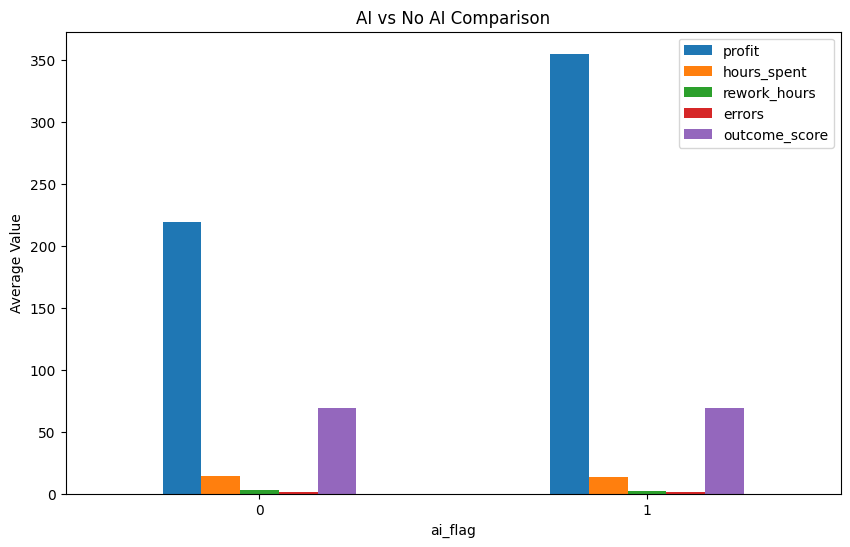

In [38]:

comparison.plot(kind='bar', figsize=(10,6))
plt.title("AI vs No AI Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.show()

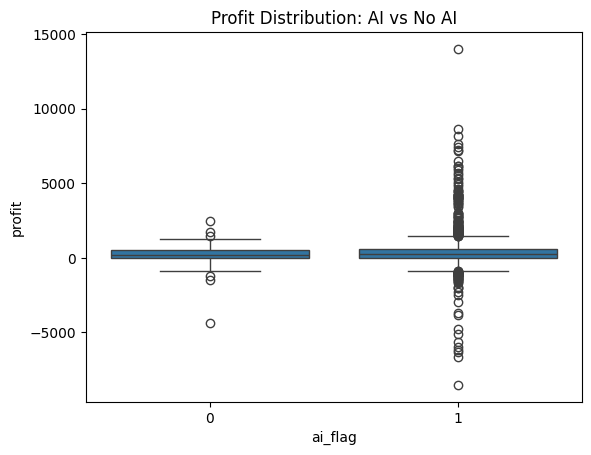

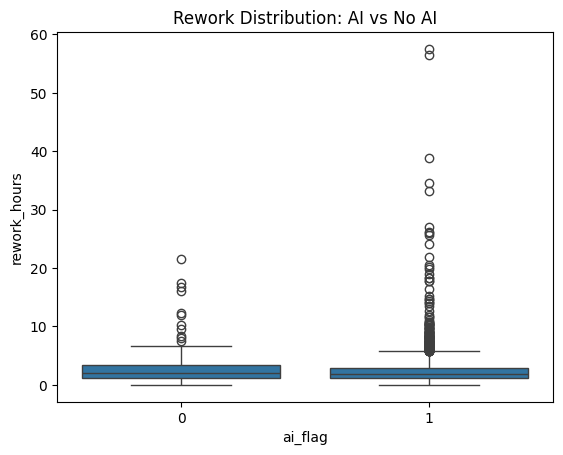

In [39]:
# Profit distribution
sns.boxplot(x='ai_flag', y='profit', data=df_productivity)
plt.title("Profit Distribution: AI vs No AI")
plt.show()

# Rework distribution
sns.boxplot(x='ai_flag', y='rework_hours', data=df_productivity)
plt.title("Rework Distribution: AI vs No AI")
plt.show()

In [40]:
from scipy.stats import ttest_ind

ai = df_productivity[df_productivity['ai_flag'] == 1]['profit']
no_ai = df_productivity[df_productivity['ai_flag'] == 0]['profit']

t_stat, p_val = ttest_ind(ai, no_ai, equal_var=False)

print(f"T-test statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")

T-test statistic: 2.491
P-value: 0.01368


### AI vs No AI Comparison

AI-assisted tasks show a clear increase in average profit (+61.8%) alongside a reduction in execution time (-8.5%), indicating improved operational efficiency.

Contrary to expectations, rework hours decrease (-19.4%) and error rates remain stable, suggesting that AI usage does not significantly deteriorate output quality in this dataset.

However, distributional analysis reveals higher variability in profit for AI-assisted tasks, with more extreme positive and negative outcomes. This indicates increased performance volatility.

The t-test confirms that the difference in profit between AI and non-AI tasks is statistically significant (p < 0.05).

Overall, AI appears to improve both efficiency and profitability on average, but introduces greater uncertainty in outcomes, highlighting the importance of managing variability and risk.


# Trade-off Analysis


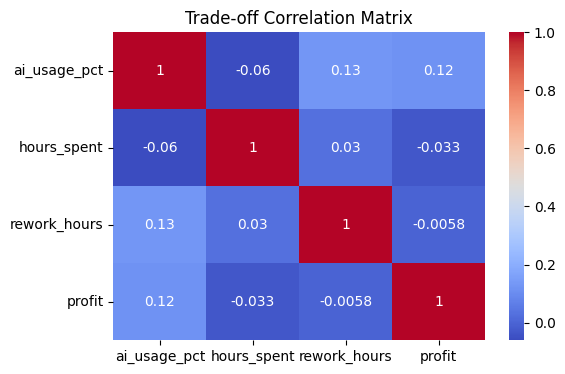

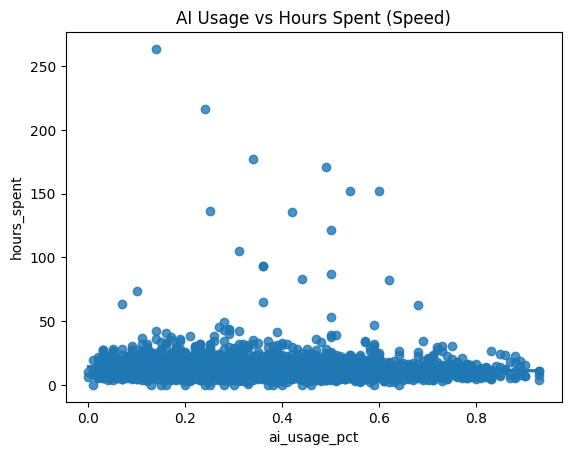

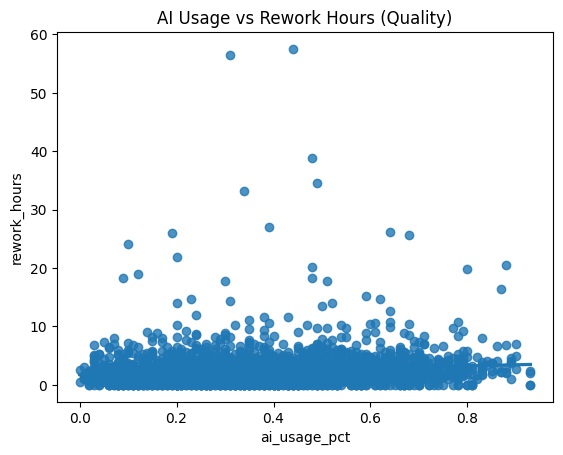

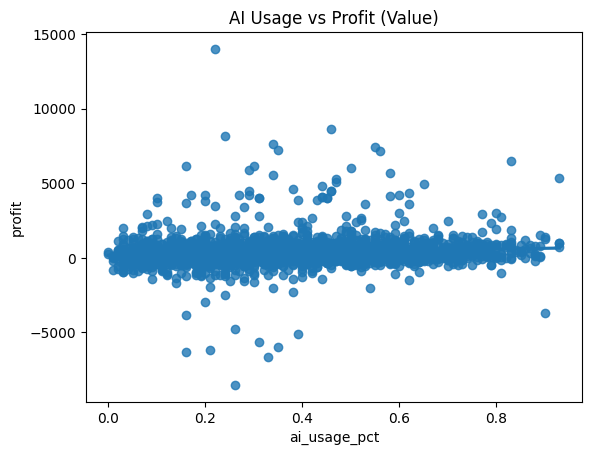

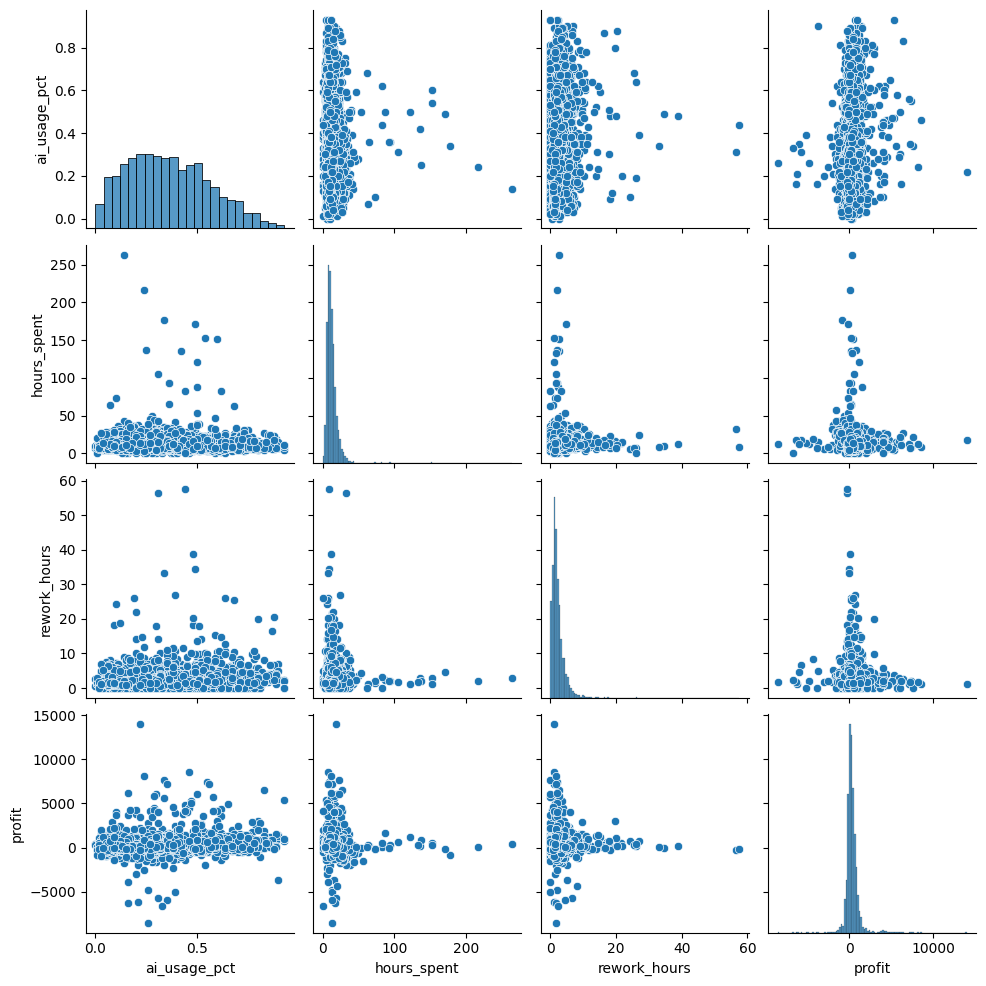

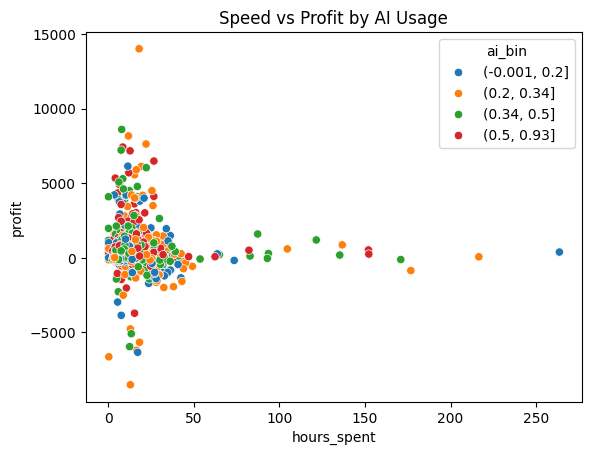

In [ ]:

# 1. Correlation tra variabili chiave
tradeoff_corr = df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(tradeoff_corr, annot=True, cmap='coolwarm')
plt.title("Trade-off Correlation Matrix")
plt.show()


# 2. AI vs Speed (tempo)
sns.regplot(x='ai_usage_pct', y='hours_spent', data=df_productivity)
plt.title("AI Usage vs Hours Spent (Speed)")
plt.show()


# 3. AI vs Quality (rework)
sns.regplot(x='ai_usage_pct', y='rework_hours', data=df_productivity)
plt.title("AI Usage vs Rework Hours (Quality)")
plt.show()


# 4. AI vs Profit (valore)
sns.regplot(x='ai_usage_pct', y='profit', data=df_productivity)
plt.title("AI Usage vs Profit (Value)")
plt.show()


# 5. Visione globale (tutte le relazioni insieme)
sns.pairplot(df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']])
plt.show()


# 6. Trade-off avanzato: Speed vs Profit colorato per AI
df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=4)

sns.scatterplot(
    x='hours_spent',
    y='profit',
    hue='ai_bin',
    data=df_productivity
)
plt.title("Speed vs Profit by AI Usage")
plt.show()

# Non linear effect of AI
AI aumenta il profit sempre allo stesso modo?
👉 oppure cambia comportamento (non lineare)

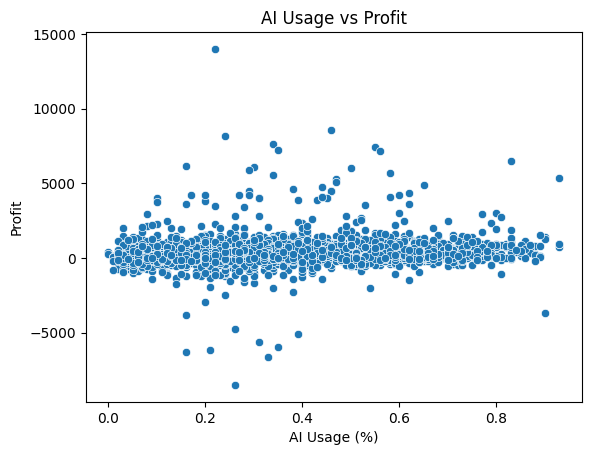

In [57]:
# =========================
# AI vs Profit (base)
# =========================

sns.scatterplot(x='ai_usage_pct', y='profit', data=df_productivity)
plt.title("AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

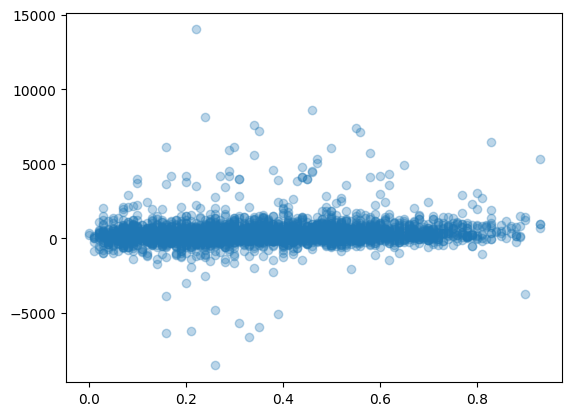

In [60]:
# =========================
# Non-linear trend (LOWESS)
# =========================

sns.regplot(
    x='ai_usage_pct',
    y='profit',
    data=df_productivity,
    lowess=True,
    scatter_kws={'alpha':0.3}
)

plt.title("Non-linear Trend: AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

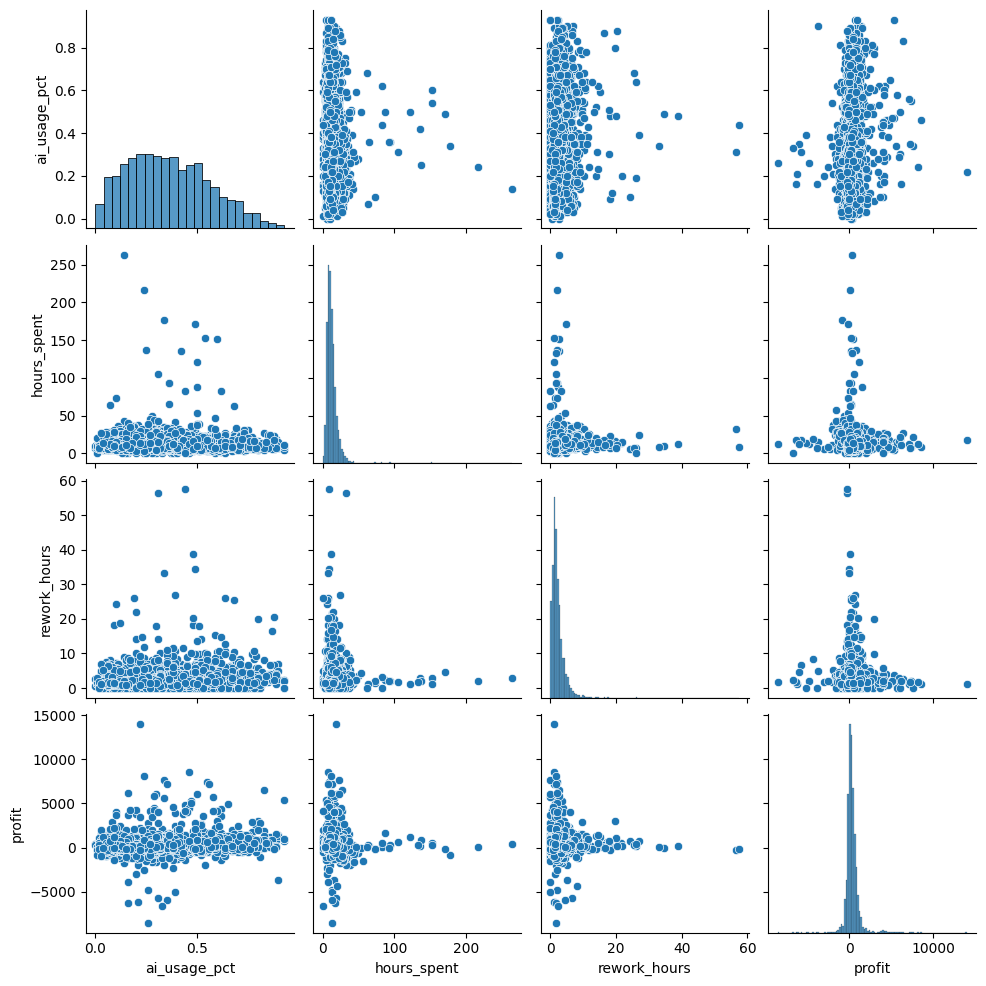

In [ ]:
sns.pairplot(df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']])
plt.show()

In [52]:
# =========================
# Binning AI usage
# =========================

df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=5)

ai_bin_analysis = df_productivity.groupby('ai_bin')['profit'].mean()

print(ai_bin_analysis)

ai_bin
(-0.001, 0.17]    234.676653
(0.17, 0.29]      260.656167
(0.29, 0.4]       334.318858
(0.4, 0.54]       449.274174
(0.54, 0.93]      509.226388
Name: profit, dtype: float64


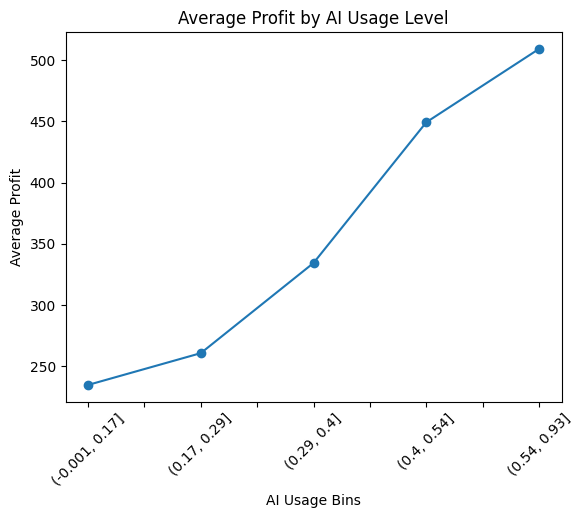

In [53]:
ai_bin_analysis.plot(kind='line', marker='o')

plt.title("Average Profit by AI Usage Level")
plt.xlabel("AI Usage Bins")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.show()

# Threshold detection
“fino a che livello AI aiuta… e da quando smette (o peggiora)?”

In [ ]:
df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=5)

In [62]:
# =========================
# Average profit per bin
# =========================

ai_threshold = df_productivity.groupby('ai_bin')['profit'].mean()

print(ai_threshold)

ai_bin
(-0.001, 0.17]    234.676653
(0.17, 0.29]      260.656167
(0.29, 0.4]       334.318858
(0.4, 0.54]       449.274174
(0.54, 0.93]      509.226388
Name: profit, dtype: float64


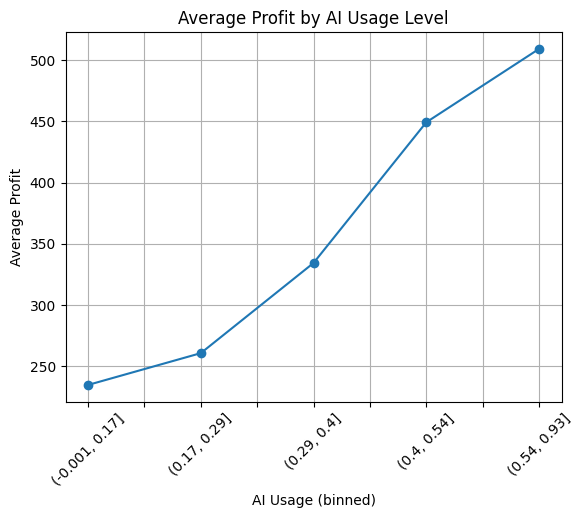

In [63]:
# =========================
# Plot threshold
# =========================

ai_threshold.plot(kind='line', marker='o')

plt.title("Average Profit by AI Usage Level")
plt.xlabel("AI Usage (binned)")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Loss Analysis 

1.	AI → cambia tempo
2.	AI → cambia rework
3.	rework → ha un costo
4.	costo → impatta profit

⸻

quindi:

AI non impatta direttamente il profit
lo fa tramite costi operativi

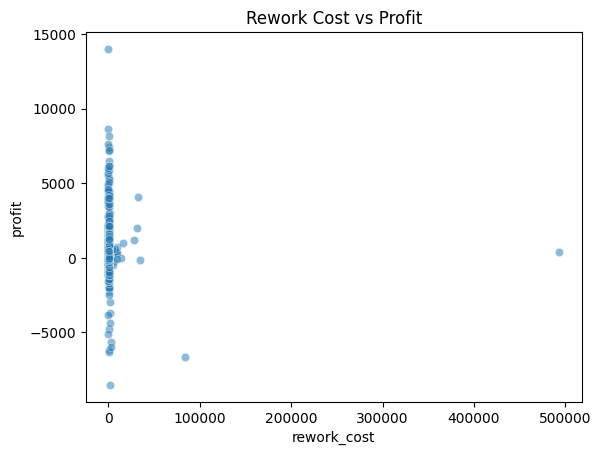

rework_bin
(-0.001, 59.761]        460.617185
(59.761, 104.253]       357.197279
(104.253, 179.85]       371.838681
(179.85, 493491.654]    210.676820
Name: profit, dtype: float64


In [67]:
df_productivity['rework_cost'] = (
    df_productivity['rework_hours'] * df_productivity['cost_per_hour']
)

# relazione
sns.scatterplot(x='rework_cost', y='profit', data=df_productivity, alpha=0.5)
plt.title("Rework Cost vs Profit")
plt.show()

# binning
df_productivity['rework_bin'] = pd.qcut(df_productivity['rework_cost'], q=4)

loss_analysis = df_productivity.groupby('rework_bin')['profit'].mean()

print(loss_analysis)

In [ ]:
df_productivity[['rework_cost', 'profit']].corr()

: 

In [ ]:
df_productivity['rework_bin'] = pd.qcut(df_productivity['rework_cost'], q=4)

df_productivity.groupby('rework_bin')['profit'].mean()

In [ ]:
sns.boxplot(x='rework_bin', y='profit', data=df_productivity)
plt.title("Profit by Rework Cost Level")
plt.xticks(rotation=45)
plt.show()